[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/01_foundations/03_lists_data_structures.ipynb)

# 📓 Notebook 3 — Lists & Sequence Structures: Records, Logs, and Batches

> **Module:** Data Structures · **Estimated time:** 35–45 min · **Difficulty:** Beginner

A single variable holds one value. Real work has *many* values: a batch of customer messages, a column of prices, a log file with thousands of lines, a list of prompts to send to a model. **Sequences** — lists, tuples, strings — are how Python organises collections of values. They are the bedrock on which NumPy arrays and pandas DataFrames are built later in the course.

**Our running scenario.** Imagine you've just inherited the data behind a small SaaS support desk: a **queue of support tickets**, a column of **call latencies** from monitoring, and a **roster of customers**. Your job all notebook long is the same job you'll do a thousand times in practice — *take a batch of records and slice it, filter it, reshape it, and summarise it.* We meet each tool exactly when that job demands it: indexing to grab one ticket, slicing to take "the latest ten", comprehensions to filter the batch, tuples to lock down a single record, nested lists to lay the roster out as a table.

> 🧭 **Mental model for the whole notebook.** Picture a list as a **numbered row of boxes on a conveyor belt** — box `0`, box `1`, box `2`, …, each holding one record. *Indexing* reaches into one box; *slicing* lifts off a contiguous run of boxes; a *comprehension* runs the whole belt past you and keeps the boxes you want. And one subtlety we'll prove carefully: the box holds a **label pointing at an object**, not the object itself — the source of the most famous list bug there is.

## 🎯 Learning objectives

By the end of this notebook you can:

1. Create, access and modify Python **lists**.
2. Master **indexing** and **slicing** — the most important syntax in data science.
3. Use the key list **methods** (`append`, `extend`, `insert`, `remove`, `pop`, `sort`, …).
4. Write concise **list comprehensions** for filtering and transformation.
5. Know when to use a **tuple** (immutable) instead of a list.
6. Work with **strings as sequences** (indexing, slicing, splitting).
7. Use **nested lists** to represent small tables — and know when to graduate to pandas.

## ✅ Prerequisites

Notebooks 1 and 2.

## 1. What is a list? — one box per record

Our support queue is a perfect first list: an *ordered* collection of ticket IDs, in the order they arrived. A **list** is exactly that — an ordered, *mutable* collection of values, of any type, even other lists.

```python
prices    = [4.99, 9.50, 2.30, 12.75]           # ← homogeneous (all floats)
tickets   = ["T-100", "T-101", "T-102"]         # ← strings
mixed     = [1, "apple", 3.14, True]            # ← legal, but rarely useful
empty     = []                                  # ← yes, lists can be empty
```

Picture it as the **numbered row of boxes** from the intro. Each box has an **index** (its position) starting at **0**, and holds one value.

In [1]:
# A few common ways to create a list — flavoured with real data
prices  = [4.99, 9.50, 2.30, 12.75]
tickets = ["T-100", "T-101", "T-102", "T-103"]
empty   = []

print("prices :", prices)
print("tickets:", tickets)
print("empty  :", empty)
print(f"len(prices) = {len(prices)}")


prices : [4.99, 9.5, 2.3, 12.75]
tickets: ['T-100', 'T-101', 'T-102', 'T-103']
empty  : []
len(prices) = 4


## 2. Indexing — reaching into one box

A queue is only useful if you can pull *one specific* ticket out of it — the first to be served, or the most recent to arrive. That's **indexing**: name the box number, get the value.

Python uses **zero-based** indexing: the first item is at index `0`, the last at `len(list) - 1`. You can also count from the *end* with **negative** indices — exactly what you want for "the most recent log line" without computing the length first.

```
 tickets = ["T-100", "T-101", "T-102", "T-103"]
 idx     :    0        1        2        3
 neg     :   -4       -3       -2       -1
```

In [2]:
tickets = ["T-100", "T-101", "T-102", "T-103"]

print(f"First       tickets[0]  = {tickets[0]!r}")
print(f"Second      tickets[1]  = {tickets[1]!r}")
print(f"Last        tickets[-1] = {tickets[-1]!r}")
print(f"Second-last tickets[-2] = {tickets[-2]!r}")


First       tickets[0]  = 'T-100'
Second      tickets[1]  = 'T-101'
Last        tickets[-1] = 'T-103'
Second-last tickets[-2] = 'T-102'


> ⚠️ Accessing an index that doesn't exist raises `IndexError: list index out of range`. Always check `len(...)` if you're not sure — and reach for `tickets[-1]` instead of `tickets[len(tickets)-1]`.

## 3. Slicing — lifting off a chunk of the belt

One box at a time is fine for a single ticket. But the questions you'll actually ask the queue are about *runs* of boxes: *"show me the latest ten log lines", "skip the header row", "split features from the target".* For that you don't index one box — you **slice** off a contiguous stretch.

**This is the single most important syntax to memorise.** Every time you see `data[0:100]` in a machine-learning or AI notebook, this is what's happening.

```
data[ start : stop : step ]
        │      │      │
        │      │      └─ how far to jump (default 1)
        │      └──────── exclusive end (default end of list)
        └─────────────── inclusive start (default 0)
```

Rules:

- The **stop** index is *exclusive* (`[0:3]` gives indices 0, 1, 2 — *not* 3).
- Any of the three can be omitted.
- Negative steps reverse the sequence.

You'll use slicing for things like:

- *"give me the first 100 rows for a quick look"* → `df[:100]`
- *"give me the most recent 10 log lines"* → `lines[-10:]`
- *"skip the header"* → `rows[1:]`
- *"split features and target"* → `row[:-1]`, `row[-1]`

In [3]:
# A week of daily latencies (a "log column" from monitoring)
latency_ms = [180, 195, 210, 178, 232, 169, 204, 199, 217, 188]

print(f"All              : {latency_ms}")
print(f"First three      : {latency_ms[0:3]}")
print(f"Last three       : {latency_ms[-3:]}")
print(f"Skip first       : {latency_ms[1:]}")
print(f"Drop last        : {latency_ms[:-1]}")
print(f"Every 2nd        : {latency_ms[::2]}")
print(f"Reversed         : {latency_ms[::-1]}")


All              : [180, 195, 210, 178, 232, 169, 204, 199, 217, 188]
First three      : [180, 195, 210]
Last three       : [199, 217, 188]
Skip first       : [195, 210, 178, 232, 169, 204, 199, 217, 188]
Drop last        : [180, 195, 210, 178, 232, 169, 204, 199, 217]
Every 2nd        : [180, 210, 232, 204, 217]
Reversed         : [188, 217, 199, 204, 169, 232, 178, 210, 195, 180]


> 🎯 **A useful mnemonic.** The bounds in `data[a:b]` mark the **gaps between items**, not the items themselves. That's why `data[0:3]` has exactly 3 items: the gap at position 0 (before the first), and the gap at position 3 (after the third).

```
  [ 180 , 195 , 210 , 178 , ... ]
   ↑     ↑     ↑     ↑
   0     1     2     3       ← slice boundaries (between items)
```

### 📊 Seeing a slice

The slicing rules stick faster as a picture. Below, each bar is one **box** of `latency_ms`; the dark bars are exactly the contiguous run that `latency_ms[-3:]` lifts off the belt.

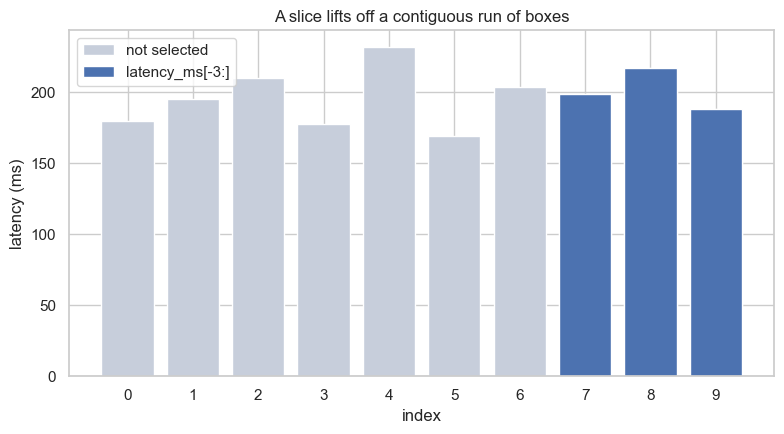

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

latency_ms = [180, 195, 210, 178, 232, 169, 204, 199, 217, 188]
x = list(range(len(latency_ms)))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x, latency_ms, color="#C7CEDB", label="not selected")
ax.bar(x[-3:], latency_ms[-3:], color="#4C72B0", label="latency_ms[-3:]")
ax.set_xlabel("index")
ax.set_ylabel("latency (ms)")
ax.set_title("A slice lifts off a contiguous run of boxes")
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.show()

---

### ✋ Quick exercise (~2 min) — Grab the recent window

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

You have a week+ of daily API latency readings (ms). Using **only indexing and slicing**, print the **last 3** readings, the **most recent** reading, and **every other** reading.

```python
latency_ms = [180, 195, 210, 178, 232, 169, 204]
```

In [5]:
# ✍️ Your turn 👇
latency_ms = [180, 195, 210, 178, 232, 169, 204]

# TODO: print the last 3 readings
# TODO: print the most recent (last) reading
# TODO: print every 2nd reading


<details>
<summary>✅ <b>Solution</b></summary>

```python
print("Last 3   :", latency_ms[-3:])
print("Latest   :", latency_ms[-1])
print("Every 2nd:", latency_ms[::2])
```

Negative indices count from the end (`-1` is the last item), and a slice with a step (`[::2]`) skips elements — no loop required.
</details>

## 4. Modifying lists — the queue changes

A real queue isn't frozen: tickets get re-prioritised, a bad score gets corrected, a resolved item is removed. Because a list is **mutable**, you can change it in place after creation — and that's exactly the line that separates a list from a tuple (which we meet in §8).

In [6]:
scores = [0.85, 0.92, 0.78, 0.96, 0.88]
print(f"Original : {scores}")

# Replace one element
scores[2] = 0.82
print(f"After scores[2] = 0.82 : {scores}")

# Replace a slice (length can differ!)
scores[1:3] = [0.99, 0.99, 0.99]
print(f"After scores[1:3] = [...]  : {scores}")

# Delete an item
del scores[0]
print(f"After del scores[0]       : {scores}")


Original : [0.85, 0.92, 0.78, 0.96, 0.88]
After scores[2] = 0.82 : [0.85, 0.92, 0.82, 0.96, 0.88]
After scores[1:3] = [...]  : [0.85, 0.99, 0.99, 0.99, 0.96, 0.88]
After del scores[0]       : [0.99, 0.99, 0.99, 0.96, 0.88]


## 5. List methods — the everyday toolkit for a growing queue

Replacing items by index (§4) is the blunt instrument. Day to day, you grow and shrink the queue with named **methods**: push a new ticket on the end, pull the next one off the front, drop a resolved one by value. These are the verbs you'll reach for constantly — each acts **in place** unless stated otherwise.

In [7]:
# Building a batch of work-items step by step
queue = []

queue.append("T-100")          # add one item at the end
queue.append("T-101")
queue.extend(["T-102", "T-103"])  # add several items at once
queue.insert(0, "T-099")       # insert at a specific position
print(f"After adding    : {queue}")

# Removing items
queue.remove("T-101")          # remove first occurrence of value
last  = queue.pop()            # remove AND return the last item
first = queue.pop(0)           # remove AND return item at index 0
print(f"\nPopped first={first!r}, last={last!r}")
print(f"After removing  : {queue}")


After adding    : ['T-099', 'T-100', 'T-101', 'T-102', 'T-103']

Popped first='T-099', last='T-103'
After removing  : ['T-100', 'T-102']


In [8]:
# Searching / counting / sorting
durations = [3, 1, 4, 1, 5, 9, 2, 6, 5, 3, 5]

print(f"durations.count(5)  = {durations.count(5)}")
print(f"durations.index(9)  = {durations.index(9)}")
print(f"5 in durations?     = {5 in durations}")

# sorted() returns a NEW list; .sort() modifies in place
print(f"sorted(durations)              : {sorted(durations)}")
print(f"sorted(durations, reverse=T)   : {sorted(durations, reverse=True)}")
durations.sort()
print(f"after durations.sort()         : {durations}")


durations.count(5)  = 3
durations.index(9)  = 5
5 in durations?     = True
sorted(durations)              : [1, 1, 2, 3, 3, 4, 5, 5, 5, 6, 9]
sorted(durations, reverse=T)   : [9, 6, 5, 5, 5, 4, 3, 3, 2, 1, 1]
after durations.sort()         : [1, 1, 2, 3, 3, 4, 5, 5, 5, 6, 9]


> 💡 **Beginner trap.** `sorted(x)` returns a *new* list. `x.sort()` mutates `x` and returns `None`. People very often write `nums = nums.sort()` and end up with `nums = None`. Prefer `sorted()` unless you have a specific reason to mutate.

### Quick stats with built-ins

For any list of numbers, Python offers basic stats with no library at all:

In [9]:
# Daily token usage over a week (in millions of tokens)
tokens_m = [4.2, 5.1, 3.8, 6.3, 5.7, 4.9, 6.2]

print(f"n        = {len(tokens_m)}")
print(f"min      = {min(tokens_m)} M")
print(f"max      = {max(tokens_m)} M")
print(f"sum      = {sum(tokens_m):.1f} M")
print(f"mean     = {sum(tokens_m)/len(tokens_m):.2f} M")
print(f"range    = {max(tokens_m) - min(tokens_m):.1f} M")


n        = 7
min      = 3.8 M
max      = 6.3 M
sum      = 36.2 M
mean     = 5.17 M
range    = 2.5 M


---

### ✋ Quick exercise (~2 min) — Update the scoreboard

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

A new model evaluation just finished with a score of `0.91`. **Append** it to the list below, then report the **highest** score and the **average** score using the built-ins you just saw.

```python
scores = [0.85, 0.92, 0.78, 0.96, 0.88]
```

In [10]:
# ✍️ Your turn 👇
scores = [0.85, 0.92, 0.78, 0.96, 0.88]

# TODO: append the new score 0.91
# TODO: print the highest score
# TODO: print the average score


<details>
<summary>✅ <b>Solution</b></summary>

```python
scores.append(0.91)
print("Highest:", max(scores))
print("Average:", sum(scores) / len(scores))
```

`.append()` mutates the list in place; `max()`, `sum()` and `len()` are built-ins that work on any list of numbers.
</details>

## 6. Iterating over the queue — a recap from Notebook 2

We can now build and reshape the queue; the next reflex is to *walk* it — run the conveyor belt past us, one record at a time (the `for` loop from NB 2). Three flavours cover almost everything: loop by value alone, by `enumerate()` for index+value, or by `zip()` to walk two parallel columns in lock-step.

In [11]:
confidences = [0.95, 0.78, 0.55, 0.30, 0.91]
labels      = ["high", "high", "med",  "low", "high"]

# zip pairs the two lists element-by-element
print(f"{'#':>2}  {'conf':>5}  label")
print("-" * 18)
for i, (c, lab) in enumerate(zip(confidences, labels), start=1):
    flag = "✓" if c >= 0.8 else " "
    print(f"{i:>2}  {c:>5.2f}  {lab:<5}  {flag}")


 #   conf  label
------------------
 1   0.95  high   ✓
 2   0.78  high    
 3   0.55  med     
 4   0.30  low     
 5   0.91  high   ✓


> 💡 `zip(a, b, c)` walks through any number of lists in lock-step. If they have different lengths it stops at the shortest. This is *the* pattern for "I have parallel columns and want to walk them together".

## 7. List comprehensions — filter the batch in one line

Look back at what we keep doing to the queue: start an empty list, loop over the records, keep or transform each one, append the result. That four-line ritual is so common Python gives it a one-line form — the **list comprehension**. It's the most Pythonic way to filter and reshape a batch, and you'll see it everywhere in modern data and AI code.

```
[expression for item in iterable if condition]
     │            │                   │
     │            │                   └─ filter (optional)
     │            └────────────────────── source
     └─────────────────────────────────── what to put in the new list
```

In [12]:
# Same task two ways
# 1) traditional loop
squares_long = []
for i in range(1, 6):
    squares_long.append(i ** 2)

# 2) list comprehension
squares_short = [i ** 2 for i in range(1, 6)]

print("traditional loop :", squares_long)
print("comprehension    :", squares_short)


traditional loop : [1, 4, 9, 16, 25]
comprehension    : [1, 4, 9, 16, 25]


### 🔬 What actually happens — a comprehension *is* a `for` loop

A list comprehension is not magic and not a different feature — it is **exactly** a build-by-loop pattern, written on one line. The Python interpreter literally unrolls it into a loop. Reading it that way makes every comprehension you'll ever meet legible.

Here is the **desugaring** — the same comprehension shown next to the loop it expands to:

```text
[ i ** 2  for i in range(1, 6) ]
│ │           │    │
│ │           │    └─ the iterable to walk
│ │           └────── the loop variable
│ └────────────────── the expression appended each step
└──────────────────── the new list being built

        ▼  expands to  ▼

result = []                  # start an empty list
for i in range(1, 6):        # for item in iterable:
    result.append(i ** 2)    #     result.append( expression )
```

So a comprehension always says the same three things, in this order: **what to build (`result = []`), what to loop over (`for i in ...`), what to add each time (`.append(expr)`).**


### Reading order vs writing order

The one trick that confuses beginners: the comprehension is **written** with the expression *first*, but **executed** in loop order. Read it left-to-right by jumping to the `for` first:

```text
[  i ** 2   for i in range(1, 6)  ]
   └─ (3) ─┘ └──── (1) ─────────┘

   (1) FIRST  read the `for ... in ...`   → "for each i in 1..5"
   (2) THEN   (an `if`, if present)        → "(keep it when ...)"
   (3) LAST   the expression on the left   → "collect i ** 2"
```

Say it out loud as a sentence: *"for each `i` in `range(1, 6)`, collect `i ** 2`."* That sentence **is** the loop.


In [13]:
# PROOF: a comprehension and its hand-written loop produce IDENTICAL results.

# (1) the loop form, spelled out
result_loop = []
for i in range(1, 6):
    result_loop.append(i ** 2)

# (2) the comprehension — the SAME three pieces on one line
result_comp = [i ** 2 for i in range(1, 6)]

print("loop          :", result_loop)
print("comprehension :", result_comp)
print("identical?    :", result_loop == result_comp)   # True


loop          : [1, 4, 9, 16, 25]
comprehension : [1, 4, 9, 16, 25]
identical?    : True


### Adding a filter — the `if` is just an `if` inside the loop

A *filtered* comprehension `[expr for x in it if cond]` expands the same way, with the `if` wrapped around the `append`:

```text
[ x  for x in nums  if x > 0 ]

        ▼  expands to  ▼

result = []
for x in nums:
    if x > 0:              # ← the filter: only then do we append
        result.append(x)
```

The next cell proves the filtered form and its loop match exactly:


In [14]:
# PROOF: a FILTERED comprehension equals its expanded loop.
nums = [12, -3, 8, -1, 15, 0, 22, -7, 18]

# (1) loop form: filter, then collect
positives_loop = []
for x in nums:
    if x > 0:
        positives_loop.append(x)

# (2) comprehension form
positives_comp = [x for x in nums if x > 0]

print("loop          :", positives_loop)
print("comprehension :", positives_comp)
print("identical?    :", positives_loop == positives_comp)   # True


loop          : [12, 8, 15, 22, 18]
comprehension : [12, 8, 15, 22, 18]
identical?    : True


> 🧠 **Mental model.** Whenever a comprehension looks dense, mentally *un-fold* it back into the loop:
> `result = []` → `for x in iterable:` → (`if cond:`) → `result.append(expr)`.
> If you can write that loop, you understand the comprehension — they are the **same code**, and produce the **same list**.


In [15]:
# With a filter — keep only the values you want
durations = [12, -3, 8, -1, 15, 0, 22, -7, 18]

valid     = [x for x in durations if x > 0]
doubled   = [2 * x for x in durations]
squared_evens = [x ** 2 for x in durations if x % 2 == 0]

print(f"valid (>0)      : {valid}")
print(f"doubled         : {doubled}")
print(f"squared evens   : {squared_evens}")


valid (>0)      : [12, 8, 15, 22, 18]
doubled         : [24, -6, 16, -2, 30, 0, 44, -14, 36]
squared evens   : [144, 64, 0, 484, 324]


### A real-world comprehension — token cost per call

Suppose you have a list of "tokens used" per call. You want the **dollar cost** of each call — a one-liner with a comprehension.

In [16]:
# Output tokens are pricier — let's use $0.005 / 1K (a typical output rate)
tokens_per_call = [612, 248, 1180, 540, 905, 720]
price_per_1k    = 0.005

costs = [t / 1000 * price_per_1k for t in tokens_per_call]
print("Costs (USD):", [round(c, 4) for c in costs])

# Same, but only keep calls that cost more than half a cent
expensive = [round(c, 4) for c in costs if c > 0.005]
print("Expensive  :", expensive)


Costs (USD): [0.0031, 0.0012, 0.0059, 0.0027, 0.0045, 0.0036]
Expensive  : [0.0059]


### The comprehension's output, as a bar

The comprehension turned `tokens_per_call` into a list of `costs`. A bar chart of that result makes the priciest calls jump out instantly.

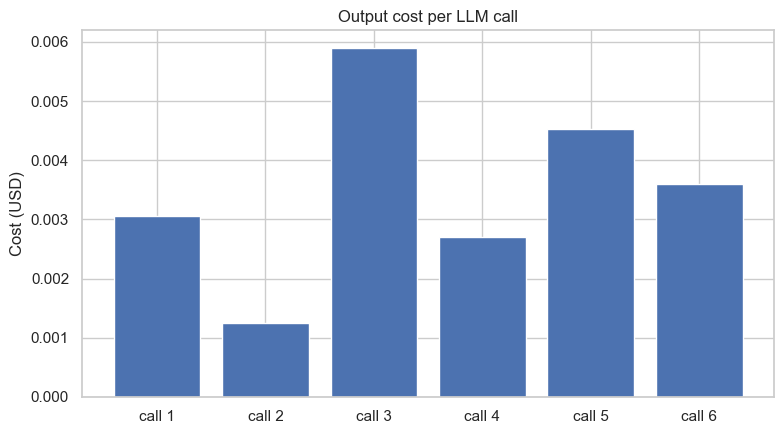

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 4.5))
labels = [f"call {i+1}" for i in range(len(costs))]
ax.bar(labels, costs, color='#4C72B0')
ax.set_ylabel("Cost (USD)")
ax.set_title("Output cost per LLM call")
plt.tight_layout()
plt.show()


**How to read it:** taller bars are the calls that produced more tokens — those are the ones worth shortening to cut cost.

> 🎯 **Rule of thumb.** Use a comprehension when the loop body is *one expression that produces an item*. If it grows beyond that — multiple statements, side-effects, complex branching — use an ordinary `for` loop. **Readability beats cleverness.**

---

### ✋ Quick exercise (~2 min) — Flag the heavy calls

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Given the token count of each LLM call, use **list comprehensions** to build (1) a list of only the *heavy* calls that used **more than 1000 tokens**, and (2) a list of every count expressed **in thousands** (divide by 1000).

```python
tokens_per_call = [320, 1450, 880, 2100, 540, 1190]
```

In [18]:
# ✍️ Your turn 👇
tokens_per_call = [320, 1450, 880, 2100, 540, 1190]

heavy = ...        # TODO: comprehension keeping only counts > 1000
in_thousands = ... # TODO: comprehension dividing each count by 1000


<details>
<summary>✅ <b>Solution</b></summary>

```python
heavy = [t for t in tokens_per_call if t > 1000]
in_thousands = [t / 1000 for t in tokens_per_call]
print(heavy)          # [1450, 2100, 1190]
print(in_thousands)   # [0.32, 1.45, 0.88, 2.1, 0.54, 1.19]
```

A comprehension's `if` clause filters which items are kept, while the expression at the front transforms each item that survives.
</details>

## 8. Tuples — when a record must *not* change

A list is mutable, which is exactly what we wanted for the queue. But sometimes mutability is a *hazard*: a single customer record — `(name, mrr, plan)` — or an API endpoint `(host, port, path)` should travel as one fixed bundle that no stray line of code can quietly edit. For that, you want a **tuple**: like a list, but frozen once built.

A tuple is created with parentheses (or just commas):

```python
api_endpoint = ("api.example.com", 443, "/v1/chat")    # (host, port, path)
rgb          = (255, 128, 0)
record       = ("Alice", 32, "Premium")
```

Use tuples for things that conceptually belong together and shouldn't change — coordinates, RGB colours, a single row of a table, or anything you want to use as a dictionary key (lists can't be keys; tuples can).

### 🧠 Mental model — list vs tuple in memory

Both lists and tuples are sequences, but they live in memory differently:

```
  LIST  (mutable, resizable)
  ┌──────────────────────────────────────────────────┐
  │  header  │  ptr  │  ptr  │  ptr  │  ⋯  │ spare   │  ← grows by re-allocating
  └──────────┴───┬───┴───┬───┴───┬───┴─────┴─────────┘
                 ▼       ▼       ▼
              "apple"  "pear"  "plum"

  TUPLE (immutable, fixed-size)
  ┌──────────────────────────────────────┐
  │  header  │  ptr  │  ptr  │  ptr  │   │  ← exact size; no spare slots
  └──────────┴───┬───┴───┬───┴───┬───┴───┘
                 ▼       ▼       ▼
              "apple"  "pear"  "plum"
```

Practical consequences: appending to a list is O(1) amortised because of the spare slots; tuples have no spare slots and so are cheaper *per element* in memory but can't grow.


In [19]:
# Tuples support indexing / slicing / iteration just like lists
endpoint = ("api.example.com", 443, "/v1/chat")
print(f"host = {endpoint[0]}, port = {endpoint[1]}, path = {endpoint[2]}")

# Unpacking — VERY common
host, port, path = endpoint
print(f"After unpacking: host={host}, port={port}, path={path}")

# Tuples are immutable — this raises an error
try:
    endpoint[0] = "evil.com"
except TypeError as e:
    print(f"\nTypeError (good!): {e}")


host = api.example.com, port = 443, path = /v1/chat
After unpacking: host=api.example.com, port=443, path=/v1/chat

TypeError (good!): 'tuple' object does not support item assignment


### Tuple-unpacking is your friend

You can return *multiple values* from a function as a tuple and unpack them at the call site. AI/API SDKs do this a lot.

In [20]:
def usage_summary(values):
    return min(values), max(values), sum(values) / len(values)   # returns a tuple

lo, hi, mean = usage_summary([4.2, 5.1, 3.8, 6.3, 5.7])
print(f"min = {lo}, max = {hi}, mean = {mean:.2f}")

# Pythonic swap — no temporary variable required
a, b = 1, 2
a, b = b, a
print(f"swapped: a={a}, b={b}")


min = 3.8, max = 6.3, mean = 5.02
swapped: a=2, b=1


## 9. Strings as sequences — the same belt, one character per box

Here's a quietly useful payoff: a string *is* a sequence too — an immutable row of boxes with one character each. So every indexing and slicing trick you just learned for the queue works unchanged on a ticket ID or a SKU. That's invaluable for pulling apart identifiers, file paths, and short log lines without reaching for `re`.

In [21]:
text = "SKU-3491-RED"

print(f"len(text)  = {len(text)}")
print(f"text[0]    = {text[0]!r}")
print(f"text[-3:]  = {text[-3:]!r}    # the colour suffix")
print(f"text[:3]   = {text[:3]!r}    # the SKU prefix")
print(f"text[::-1] = {text[::-1]!r}")

# Most useful string-as-list operations
parts = text.split("-")
print(f"\nSplit on '-': {parts}")
print(f"Joined back  : {'-'.join(parts)!r}")


len(text)  = 12
text[0]    = 'S'
text[-3:]  = 'RED'    # the colour suffix
text[:3]   = 'SKU'    # the SKU prefix
text[::-1] = 'DER-1943-UKS'

Split on '-': ['SKU', '3491', 'RED']
Joined back  : 'SKU-3491-RED'


## 10. Nested lists — laying the roster out as a table

Our customer roster has *several fields per customer* — name, MRR, months active, plan. A flat list can't hold that shape, but a **list of lists** can: one inner list per row, exactly like a spreadsheet. It's perfect for a handful of records (and notice each row unpacks just like the tuples from §8). For anything bigger you'll graduate to pandas in Notebook 7.

In [22]:
# columns: customer, mrr_eur, months_active, plan
customers = [
    ["Acme Inc.",      1_250,  18, "Premium"],
    ["Beta GmbH",        420,   7, "Standard"],
    ["Cygnus Ltd.",    5_800,  32, "Enterprise"],
    ["Delta Co.",        110,   3, "Free"],
    ["Epsilon AG",     2_900,  21, "Premium"],
]

# Header
print(f"{'Customer':<14}{'MRR (€)':>10}{'Months':>8}  {'Plan':<10}")
print("-" * 44)

# Walk the rows — note the tuple-style unpacking of each row
for row in customers:
    name, mrr, months, plan = row
    print(f"{name:<14}{mrr:>10,}{months:>8}  {plan:<10}")


Customer         MRR (€)  Months  Plan      
--------------------------------------------
Acme Inc.          1,250      18  Premium   
Beta GmbH            420       7  Standard  
Cygnus Ltd.        5,800      32  Enterprise
Delta Co.            110       3  Free      
Epsilon AG         2,900      21  Premium   


For any *real* tabular dataset, switch to pandas (Notebook 7). Nested lists are fine for tiny demos but quickly become awkward.

---

### ✋ Quick exercise (~2 min) — Find the big accounts

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Each row in this nested list is `[customer, mrr_eur]`. Loop over the rows, **unpack each row**, and print the **name** of every customer whose MRR is **above 1000**.

```python
customers = [["Acme", 1250], ["Beta", 420], ["Cygnus", 5800], ["Delta", 110]]
```

In [23]:
# ✍️ Your turn 👇
customers = [["Acme", 1250], ["Beta", 420], ["Cygnus", 5800], ["Delta", 110]]

# TODO: loop over the rows, unpack name + mrr, print names where mrr > 1000


<details>
<summary>✅ <b>Solution</b></summary>

```python
for name, mrr in customers:
    if mrr > 1000:
        print(name)
# Acme
# Cygnus
```

Each row is itself a 2-element list, so `for name, mrr in customers` unpacks it directly into two names on every iteration.
</details>

## 11. Common pitfalls — and the one that bites everyone

You now have the whole toolkit. Before the exercises, a short table of the traps that cost beginners the most time — and then a careful look at the last row, the *aliasing* trap, which is the single most surprising thing about lists and the reason we promised the "label, not the object" model back in the intro.

| Pitfall                                  | Example                                | How to avoid |
|------------------------------------------|----------------------------------------|--------------|
| Off-by-one on slice end                  | `data[0:3]` ≠ first 3 items? It does — end is exclusive. | Remember: **stop is exclusive**. |
| Confusing `sort` and `sorted`            | `nums = nums.sort()` → `None`          | Use `sorted()` unless you must mutate in place. |
| Modifying a list while iterating         | `for x in lst: lst.remove(x)` skips items | Iterate over a **copy** (`for x in lst[:]`) or build a new list. |
| Two names pointing to the **same** list  | `b = a; b.append(1)` changes `a` too   | Copy with `a.copy()`, `list(a)`, or `a[:]`. |
| Treating tuples like lists               | `(1, 2)[0] = 99` → `TypeError`         | Tuples are *immutable* — rebuild instead. |

In [24]:
# The "same list under two names" trap — important to understand
a = [1, 2, 3]
b = a              # b refers to the SAME list, not a copy
b.append(99)

print(f"a = {a}")  # surprising? both changed!
print(f"b = {b}")

# A real copy:
a = [1, 2, 3]
b = a.copy()       # or list(a) or a[:]
b.append(99)

print(f"\nAfter explicit copy:")
print(f"a = {a}")
print(f"b = {b}")


a = [1, 2, 3, 99]
b = [1, 2, 3, 99]

After explicit copy:
a = [1, 2, 3]
b = [1, 2, 3, 99]


### 🔬 What actually happens — `b = a` does **not** copy the list

This is the single biggest beginner trap with lists, so let's slow it right down. The line `b = a` copies the **name's target**, not the list. A name in Python is a *label* that points at an object; `=` makes another label point at the **same object**.

```text
a = [1, 2, 3]

   a ──────────────►  ┌─────────────┐
                      │ list object │  [1, 2, 3]
                      └─────────────┘

b = a          # NO new list is made — b points at the SAME object

   a ──────────────►  ┌─────────────┐
                      │ list object │  [1, 2, 3]
   b ──────────────►  └─────────────┘
```

Now `a` and `b` are **two names for one list** ("aliases"). Mutating the list through *either* name is visible through the *other* — because there is only one list.

```text
b.append(99)   # changes the one shared object

   a ──────────────►  ┌─────────────┐
                      │ list object │  [1, 2, 3, 99]
   b ──────────────►  └─────────────┘
```


In [25]:
# PROOF that b = a makes NO copy — both names point at ONE object.
a = [1, 2, 3]
b = a

print("a is b :", a is b)        # True  — SAME object, not just equal
print("id(a)  :", id(a))
print("id(b)  :", id(b))         # identical id  → literally the same object

b.append(99)                     # mutate through b ...
print("a      :", a)             # ... and a sees it too:  [1, 2, 3, 99]
print("b      :", b)             #                          [1, 2, 3, 99]


a is b : True
id(a)  : 4748979840
id(b)  : 4748979840
a      : [1, 2, 3, 99]
b      : [1, 2, 3, 99]


### In-place mutation vs rebinding — the crucial distinction

Whether the alias `a` "sees" your change depends on **what kind of operation** you do to `b`:

| Operation on `b`          | What it does                              | Does `a` see it? | Same object? (`a is b`) |
|---------------------------|-------------------------------------------|:---------------:|:-----------------------:|
| `b.append(x)`             | **mutates** the existing list in place    | ✅ yes          | still `True`            |
| `b[0] = x`                | **mutates** one slot in place             | ✅ yes          | still `True`            |
| `b += [x]`                | **mutates** in place (list `+=` extends)  | ✅ yes          | still `True`            |
| `b = b + [x]`             | **rebinds** `b` to a *brand-new* list     | ❌ no           | now `False`             |
| `b = [x]`                 | **rebinds** `b` to a different list       | ❌ no           | now `False`             |

The rule: **methods and item/slice assignment mutate the object** (everyone sharing it sees the change). **Plain `=` rebinds the name** to a different object (the old sharing partner is left untouched).

⚠️ The sneaky one is `b += [x]` vs `b = b + [x]`. They look like the same thing but they are not: `+=` mutates in place; `b + [x]` builds a new list and `=` then rebinds `b` to it.


In [26]:
# PROOF: in-place mutation is shared; rebinding breaks the link.

# --- in-place: += extends the SAME object, a sees it ---
a = [1, 2, 3]
b = a
b += [99]                        # in-place extend
print("after b += [99]")
print("  a is b :", a is b)      # True  — still one object
print("  a      :", a)           # [1, 2, 3, 99]  — a changed too


after b += [99]
  a is b : True
  a      : [1, 2, 3, 99]


🔁 **Now the contrast** — rebuild `b` with `b = b + [99]` (a brand-new list) instead of mutating it, and watch `a` stay untouched:

In [27]:
# --- rebinding: b + [..] makes a NEW object, a is left alone ---
a = [1, 2, 3]
b = a
b = b + [99]                     # NEW list, b now points elsewhere
print("after b = b + [99]")
print("  a is b :", a is b)      # False — different objects now
print("  a      :", a)           # [1, 2, 3]   — UNCHANGED
print("  b      :", b)           # [1, 2, 3, 99]


after b = b + [99]
  a is b : False
  a      : [1, 2, 3]
  b      : [1, 2, 3, 99]


### 🖼️ Mutation vs rebinding, drawn

Both proofs above in one picture — and it's the **mirror image** of the integer case from Notebook 1. **Left:** `b.append(99)` changes the *one shared list*, so `a` sees it. **Right:** `b = b + [99]` builds a *new* list and re-points only `b`, leaving `a` alone.

> 💡 **How to read it.** Same notation as before — a boxed letter is a **name**, an arrow is “points at”, a box is an **object**. Lists are *mutable*, so an in-place change is visible through every name aliased to that object.

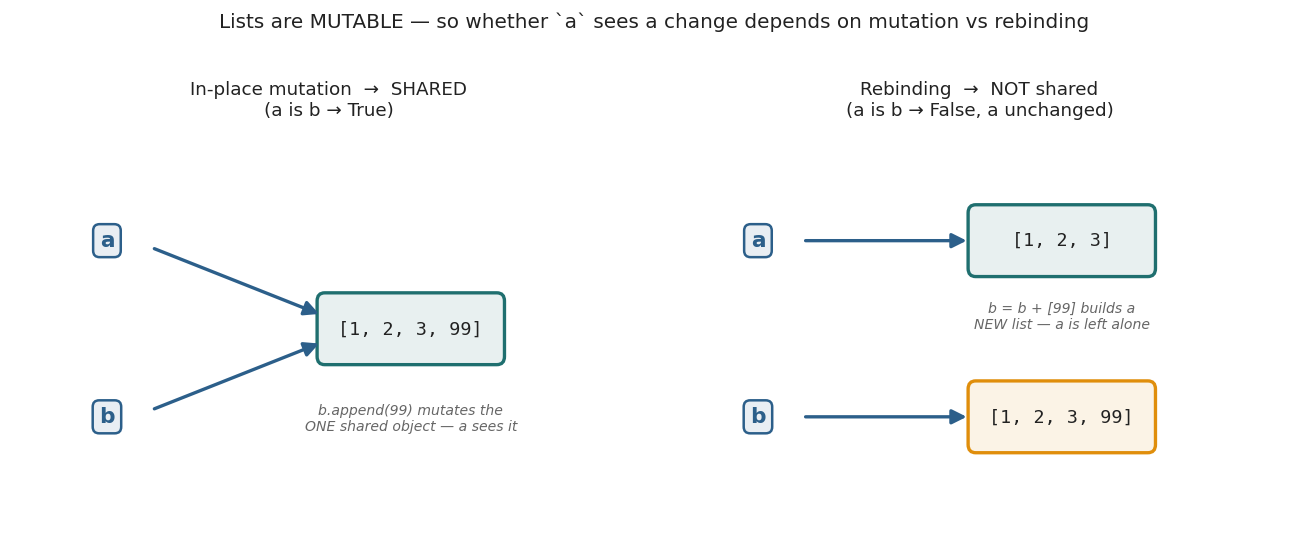

In [1]:
# Lists are MUTABLE: aliasing + in-place change IS shared; rebinding is not.
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

NAME, OBJ, NEW = "#2C5F8A", "#1F6F6F", "#E08E0B"
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

def name_tag(ax, x, y, label, color=NAME):
    ax.text(x, y, label, fontsize=13, fontweight="bold", color=color, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.3", fc=color + "1A", ec=color, lw=1.5))
def obj_box(ax, cx, y, text, color=OBJ, w=2.9, h=1.0):
    ax.add_patch(FancyBboxPatch((cx - w/2, y - h/2), w, h, boxstyle="round,pad=0.03,rounding_size=0.12",
        linewidth=2, edgecolor=color, facecolor=color + "1A"))
    ax.text(cx, y, text, ha="center", va="center", fontsize=11, family="monospace", color="#222222")

# Panel A — in-place mutation is SHARED
a = axes[0]; a.set_xlim(0, 10); a.set_ylim(0, 6); a.axis("off")
name_tag(a, 1.5, 4.3, "a"); name_tag(a, 1.5, 1.7, "b")
obj_box(a, 6.3, 3.0, "[1, 2, 3, 99]")
a.add_patch(FancyArrowPatch((2.2, 4.2), (4.9, 3.2), arrowstyle="-|>", mutation_scale=18, lw=2, color=NAME))
a.add_patch(FancyArrowPatch((2.2, 1.8), (4.9, 2.8), arrowstyle="-|>", mutation_scale=18, lw=2, color=NAME))
a.text(6.3, 1.5, "b.append(99) mutates the\nONE shared object — a sees it", fontsize=8.4, style="italic",
       color="#666666", ha="center")
a.set_title("In-place mutation  →  SHARED\n(a is b → True)", fontsize=11, color="#222222")

# Panel B — rebinding breaks the link
b = axes[1]; b.set_xlim(0, 10); b.set_ylim(0, 6); b.axis("off")
name_tag(b, 1.5, 4.3, "a"); name_tag(b, 1.5, 1.7, "b")
obj_box(b, 6.3, 4.3, "[1, 2, 3]", color=OBJ)
obj_box(b, 6.3, 1.7, "[1, 2, 3, 99]", color=NEW)
b.add_patch(FancyArrowPatch((2.2, 4.3), (4.85, 4.3), arrowstyle="-|>", mutation_scale=18, lw=2, color=NAME))
b.add_patch(FancyArrowPatch((2.2, 1.7), (4.85, 1.7), arrowstyle="-|>", mutation_scale=18, lw=2, color=NAME))
b.text(6.3, 3.0, "b = b + [99] builds a\nNEW list — a is left alone", fontsize=8.4, style="italic",
       color="#666666", ha="center")
b.set_title("Rebinding  →  NOT shared\n(a is b → False, a unchanged)", fontsize=11, color="#222222")

fig.suptitle("Lists are MUTABLE — so whether `a` sees a change depends on mutation vs rebinding",
             fontsize=12, color="#222222", y=1.02)
plt.tight_layout()
plt.show()


### Making a real copy — and why "shallow" isn't always enough

To get an independent list, copy it explicitly. For a **flat** list, any of these works and gives you a *new* object:

```text
list(a)     a[:]     a.copy()        # three ways to say "shallow copy"

   a ──────►  ┌──────────────┐
              │ list object  │  [1, 2, 3]
              └──────────────┘
   b ──────►  ┌──────────────┐       # a DIFFERENT object with equal contents
              │ list object  │  [1, 2, 3]
              └──────────────┘
```

But these are **shallow** copies: they make a new *outer* list whose slots still point at the **same inner objects**. For a flat list of numbers that's fine. For a **nested** list it bites you — the outer list is copied, but both copies share the *same inner lists*:

```text
nested = [[1, 2], [3, 4]]
shallow = nested[:]          # new OUTER list, SAME inner lists

  nested ─► ┌───────────┐        ┌────────┐
            │ slot 0 ───┼──────► │ [1, 2] │ ◄──┐
            │ slot 1 ───┼──┐     └────────┘    │
            └───────────┘  │     ┌────────┐    │  both outer lists
  shallow ─► ┌───────────┐ └───► │ [3, 4] │ ◄┐ │  point at the SAME
            │ slot 0 ───┼───────────────────┼─┘  inner lists!
            │ slot 1 ───┼─────────────────► │
            └───────────┘                   └─ shared
```

To copy *all the way down*, use `copy.deepcopy`, which recursively copies the inner lists too.


In [28]:
import copy

# A NESTED list — and a shallow copy of it.
nested  = [[1, 2], [3, 4]]
shallow = nested[:]                 # same as list(nested) / nested.copy()

print("outer lists are different objects :", nested is not shallow)   # True
print("but inner list[0] is SHARED       :", nested[0] is shallow[0]) # True!

# Mutate an INNER list through the shallow copy ...
shallow[0].append(999)
print("nested  after shallow inner-mutate:", nested)    # [[1, 2, 999], [3, 4]] — leaked!
print("shallow                           :", shallow)   # [[1, 2, 999], [3, 4]]


outer lists are different objects : True
but inner list[0] is SHARED       : True
nested  after shallow inner-mutate: [[1, 2, 999], [3, 4]]
shallow                           : [[1, 2, 999], [3, 4]]


🔧 **The fix:** `copy.deepcopy` recursively copies the inner lists too, so the two structures become fully independent:

In [29]:
# deepcopy copies the inner lists too, so they are fully independent:
nested = [[1, 2], [3, 4]]
deep   = copy.deepcopy(nested)
print("deep inner[0] is shared           :", nested[0] is deep[0])  # False
deep[0].append(999)
print("nested after deep inner-mutate    :", nested)    # [[1, 2], [3, 4]] — safe!
print("deep                              :", deep)      # [[1, 2, 999], [3, 4]]


deep inner[0] is shared           : False
nested after deep inner-mutate    : [[1, 2], [3, 4]]
deep                              : [[1, 2, 999], [3, 4]]


> 🧠 **Mental model (the same one from NB 1, now with teeth).** A variable — and every box in a list — is a **label on an object**, not a box holding a copy. `=` moves a label; it never duplicates the thing labelled. So:
> - To *share* a list: just assign (`b = a`) — and accept that mutating one affects both.
> - To get an *independent* flat list: `a[:]`, `list(a)`, or `a.copy()`.
> - To get an independent **nested** structure (like our roster of rows): `copy.deepcopy(a)`.
>
> 🎯 **Quick test in your head:** "Did I *mutate the object* (`.append`, `[i]=`, `+=`) or *rebind the name* (`=`, `+`)?" Mutation is shared; rebinding is private. This is the arrows-not-boxes picture from NB 1 — it'll matter again the moment we hit dictionaries in NB 4.

## 🔮 Predict-the-output exercise

One mental-model check before the exercises: **predict the output before running.**

### 🔮 Predict the output

```python
nums   = [3, 1, 2]
result = nums.sort()        # sort the list, capture the "result"
print(result)
print(nums)
```

It looks like `result` should hold the sorted list. Does it? Predict both lines.


In [30]:
nums   = [3, 1, 2]
result = nums.sort()        # sort the list, capture the "result"
print(result)
print(nums)


None
[1, 2, 3]


<details>
<summary>💡 <b>Answer</b></summary>

`None` and `[1, 2, 3]`. `list.sort()` sorts the list **in place** and returns `None` — it does *not* hand back a new sorted list. So `result` is `None`, while `nums` itself is now sorted. The classic bug is `nums = nums.sort()`, which throws away the list and leaves you with `None`. When you want a new sorted list and keep the original, use `sorted(nums)` instead.
</details>


## 🧪 Practice exercises

### Exercise 1 — ⭐ Filter expensive calls

Given a list of token counts per call, build a new list of the **calls that cost more than $0.001** at a price of `$0.0009 per 1K tokens`. Do it **two ways**: (a) a `for` loop, (b) a list comprehension.

In [31]:
tokens_per_call = [320, 1450, 880, 2100, 540, 1190, 670, 2050, 410]
price_per_1k    = 0.0009

# Method 1: loop
expensive_loop = []
# ...

# Method 2: comprehension
expensive_comp = []


<details>
<summary>💡 <b>Solution</b></summary>

```python
tokens_per_call = [320, 1450, 880, 2100, 540, 1190, 670, 2050, 410]
price_per_1k    = 0.0009

# Method 1
expensive_loop = []
for t in tokens_per_call:
    cost = t / 1000 * price_per_1k
    if cost > 0.001:
        expensive_loop.append(t)

# Method 2
expensive_comp = [
    t for t in tokens_per_call
    if t / 1000 * price_per_1k > 0.001
]

print("loop          :", expensive_loop)
print("comprehension :", expensive_comp)
```

Both return the same list. For a one-line filter, the comprehension is the idiomatic choice.
</details>

### Exercise 2 — ⭐⭐ Slicing practice

Given `X = [10, 20, …, 100]`, predict (without running!) what each of these returns, then check.

```python
X[0:3]
X[-3:]
X[::2]
X[1::2]
X[:-1]
X[::-1]
```

In [32]:
X = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

print("X[0:3]  =", X[0:3])
print("X[-3:]  =", X[-3:])
print("X[::2]  =", X[::2])
print("X[1::2] =", X[1::2])
print("X[:-1]  =", X[:-1])
print("X[::-1] =", X[::-1])


X[0:3]  = [10, 20, 30]
X[-3:]  = [80, 90, 100]
X[::2]  = [10, 30, 50, 70, 90]
X[1::2] = [20, 40, 60, 80, 100]
X[:-1]  = [10, 20, 30, 40, 50, 60, 70, 80, 90]
X[::-1] = [100, 90, 80, 70, 60, 50, 40, 30, 20, 10]


<details>
<summary>💡 <b>Solution & explanation</b></summary>

| Expression | Result | Why |
|---|---|---|
| `X[0:3]`  | `[10, 20, 30]`            | first 3, stop exclusive |
| `X[-3:]`  | `[80, 90, 100]`           | last 3 |
| `X[::2]`  | `[10, 30, 50, 70, 90]`    | every other, from start |
| `X[1::2]` | `[20, 40, 60, 80, 100]`   | every other, from index 1 |
| `X[:-1]`  | `[10, 20, …, 90]`         | everything but the last |
| `X[::-1]` | `[100, 90, …, 10]`        | reversed (step = -1) |

Once these six shapes are reflexive, slicing in NumPy and pandas will feel obvious.
</details>

### Exercise 3 — ⭐⭐ Monthly revenue analysis

Analyse the monthly revenue below:

1. Compute **total** annual revenue and the **average** monthly revenue.
2. Find the **best** and **worst** months (use both the value *and* the month name).
3. List all months where revenue was **above average**.

In [33]:
revenue = [125_000, 132_000, 118_000, 145_000, 139_000, 152_000,
           148_000, 136_000, 129_000, 141_000, 155_000, 162_000]
months  = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
           "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
total = sum(revenue)
avg   = total / len(revenue)

print(f"Total annual revenue : €{total:,}")
print(f"Average per month    : €{avg:,.0f}")

best_idx  = revenue.index(max(revenue))
worst_idx = revenue.index(min(revenue))
print(f"Best month  : {months[best_idx]}  (€{revenue[best_idx]:,})")
print(f"Worst month : {months[worst_idx]}  (€{revenue[worst_idx]:,})")

above = [m for m, r in zip(months, revenue) if r > avg]
print(f"Months above average: {above}")
```

**New trick used:** `zip(months, revenue)` pairs the two lists element-by-element so you can iterate over both at once. This pattern is *everywhere* in data work — and exactly what pandas does for you in one line once columns sit in a DataFrame.
</details>

### Exercise 4 — ⭐⭐ Customer-record transformation

Each row of `customers` is `[name, mrr_eur, months_active, plan]`. Compute:

1. The total MRR across all customers.
2. The **average months active** for customers on the `"Premium"` plan only.
3. A new list with **one entry per customer**: `"keep"` if MRR ≥ 1000 and months_active ≥ 12, `"watch"` if MRR ≥ 1000 and months_active < 12, `"upsell"` otherwise.

In [34]:
customers = [
    ["Acme Inc.",      1_250,  18, "Premium"],
    ["Beta GmbH",        420,   7, "Standard"],
    ["Cygnus Ltd.",    5_800,  32, "Enterprise"],
    ["Delta Co.",        110,   3, "Free"],
    ["Epsilon AG",     2_900,  21, "Premium"],
    ["Zeta SE",        1_100,   4, "Premium"],
]

# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
# 1. Total MRR
total_mrr = sum(row[1] for row in customers)
print(f"Total MRR: €{total_mrr:,}")

# 2. Average months active for Premium customers only
premium_months = [row[2] for row in customers if row[3] == "Premium"]
print(f"Avg months active (Premium): {sum(premium_months)/len(premium_months):.1f}")

# 3. Categorise each customer
def status(mrr, months):
    if mrr >= 1000 and months >= 12: return "keep"
    if mrr >= 1000:                  return "watch"
    return "upsell"

labels = [status(row[1], row[2]) for row in customers]

for row, lab in zip(customers, labels):
    print(f"  {row[0]:<14} → {lab}")
```

**Patterns used:**

- `sum(... for row in ...)` — a *generator expression*, super-handy for "sum / count by formula".
- list comprehension with a filter to pull one column.
- helper function for clear classification rules — much more readable than three nested ternaries.
</details>

### Exercise 5 — ⭐⭐ Debug me 🐞

The function below is supposed to return a list of **all even numbers** in `nums`, but it keeps returning the wrong thing. Fix it.

In [35]:
# 👇 Your fixed/corrected version goes here — write or paste it below.
def evens(nums):
    result = []
    for n in nums:
        if n % 2 == 0:
            result = n        # ← something is wrong here
    return result

print(evens([1, 2, 3, 4, 5, 6]))


6


<details>
<summary>💡 <b>Solution</b></summary>

The bug is `result = n` — that **replaces** `result` with the current number instead of *appending* to it. Fix:

```python
def evens(nums):
    result = []
    for n in nums:
        if n % 2 == 0:
            result.append(n)        # ← was: result = n
    return result

print(evens([1, 2, 3, 4, 5, 6]))   # → [2, 4, 6]
```

Or shorter, with a comprehension:

```python
def evens(nums):
    return [n for n in nums if n % 2 == 0]
```

This is *the* most common beginner bug with the accumulator pattern. Whenever you build a list, mentally check: am I `.append`-ing, or am I overwriting?
</details>

## 🧠 Stretch exercises

Four more applied exercises to deepen the material. Try them yourself before opening the solution.


### Stretch exercise A — ⭐⭐⭐ Find the top-N customers

Given the customer list below, write code that returns the names of the **top 3 customers by `mrr`**, sorted descending. Use a list comprehension and `sorted` with a key.

> 🔭 **Forward-reference.** Each record below is a *dict* — fully introduced in **NB 4** (the very next notebook). For now, read `c["mrr"]` as a named-field lookup.


In [36]:
# Your code here  👇
customers = [
    {"name": "Acme",   "mrr": 1_250},
    {"name": "Beta",   "mrr":   420},
    {"name": "Cygnus", "mrr": 5_800},
    {"name": "Delta",  "mrr":   110},
    {"name": "Epsilon","mrr": 2_900},
    {"name": "Zeta",   "mrr": 1_100},
]


<details>
<summary>💡 <b>Solution</b></summary>

```python
top3 = [c["name"] for c in
         sorted(customers, key=lambda c: c["mrr"], reverse=True)[:3]]
print(top3)        # → ['Cygnus', 'Epsilon', 'Acme']
```

**Pattern used.** `sorted(..., key=lambda c: c["mrr"], reverse=True)`
ranks; `[:3]` takes the top three; the list comprehension extracts
names. This single line is the "top-N by metric" recipe for any list
of records — the same shape you'll use on a pandas DataFrame later.

</details>

### Stretch exercise B — ⭐⭐⭐ Detect duplicate IDs

Given `ids = ['T-1','T-2','T-1','T-3','T-2','T-2','T-4']`, write code that prints:

- The count of each id.
- The list of ids that appear more than once.
- The first index where each duplicate first appeared.

Use `Counter` for the counts.


In [37]:
# Your code here  👇
ids = ['T-1','T-2','T-1','T-3','T-2','T-2','T-4']


<details>
<summary>💡 <b>Solution</b></summary>

```python
from collections import Counter

ids = ['T-1','T-2','T-1','T-3','T-2','T-2','T-4']

counts = Counter(ids)
print("Counts:", dict(counts))

dupes = [i for i, c in counts.items() if c > 1]
print("Duplicates:", dupes)

first_seen = {i: ids.index(i) for i in dupes}
print("First-seen index of each duplicate:", first_seen)
```

**Three idioms in one cell.** `Counter` gives you the counts in one
call. The list comprehension filters by count > 1. The dict
comprehension with `list.index` recovers the *first* occurrence —
useful when you need a deterministic representative for a duplicate.

</details>

### Stretch exercise C — ⭐⭐⭐ Deduplicate while preserving order

`set()` removes duplicates but **loses order**. Write a function `dedup(items)` that keeps only the **first** occurrence of each item and preserves the original order.

```python
dedup(["a", "b", "a", "c", "b", "d"])  # → ['a', 'b', 'c', 'd']
```

In [38]:
# Your code here  👇
def dedup(items):
    ...

print(dedup(["a", "b", "a", "c", "b", "d"]))


None


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def dedup(items):
    seen = set()
    out  = []
    for x in items:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out
```

**Reasoning.** This is the canonical "set as a fast membership probe, list as the ordered result" pattern. `x not in seen` is **O(1)** because `seen` is a set, so the whole function is O(n) — much faster than the naive `if x not in out:` against a list, which is O(n²). On Python 3.7+ you can also write `list(dict.fromkeys(items))` as a one-liner — dicts preserve insertion order, so this is a neat trick to know for quick scripts.
</details>

### Stretch exercise D — ⭐⭐⭐ Sliding window maximum

Given a list of numbers and a window size `k`, return a list of the **maximum value in each sliding window of size k**.

```python
sliding_max([1, 3, -1, -3, 5, 3, 6, 7], k=3)  # → [3, 3, 5, 5, 6, 7]
```

Aim for a clean O(n·k) version first — clarity beats cleverness. (There is an O(n) algorithm with `collections.deque` if you want to come back to this after the next notebook.)

In [39]:
# Your code here  👇
def sliding_max(values, k):
    ...

print(sliding_max([1, 3, -1, -3, 5, 3, 6, 7], k=3))


None


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def sliding_max(values, k):
    return [max(values[i:i+k]) for i in range(len(values) - k + 1)]
```

**Reasoning.** Slicing `values[i:i+k]` and calling `max()` on each window keeps the code obvious and one-line. The number of windows is `n - k + 1`, which is where the slightly fiddly `range(len(values) - k + 1)` comes from — off-by-one errors here are a classic interview trap, so verify by hand on the example: `len = 8, k = 3` → `8 - 3 + 1 = 6` windows, which matches the expected output. The O(n) variant with a monotonic deque is a great follow-up if you ever bump into this on very long sequences.
</details>

## 🎁 Bonus mini-project — Mini log analyser

You're handed a small server log: a list where each entry is `[level, latency_ms]`. Compute and print:

1. The **count** of each log level (`"INFO"`, `"WARN"`, `"ERROR"`).
2. The **mean latency** of `"INFO"` entries only.
3. The **slowest** entry overall (level **and** latency).
4. A new list of `(level, latency_ms)` pairs sorted by latency descending — top 3.

In [40]:
log = [
    ["INFO",  120],
    ["WARN",  450],
    ["INFO",  180],
    ["ERROR", 920],
    ["INFO",  150],
    ["WARN",  380],
    ["INFO",  210],
    ["ERROR", 1180],
    ["INFO",  175],
    ["WARN",  410],
]

# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
# 1. Count by level
levels = [row[0] for row in log]
for lvl in ("INFO", "WARN", "ERROR"):
    print(f"  {lvl:<5}: {levels.count(lvl)}")

# 2. Mean latency for INFO only
info_latencies = [row[1] for row in log if row[0] == "INFO"]
print(f"\nMean INFO latency: {sum(info_latencies)/len(info_latencies):.1f} ms")

# 3. Slowest entry
slowest = max(log, key=lambda row: row[1])
print(f"Slowest entry    : {slowest}")

# 4. Top 3 by latency, descending
top3 = sorted(log, key=lambda row: row[1], reverse=True)[:3]
print(f"Top 3 slowest    : {top3}")
```

**New trick — `key=lambda ...`.** `max`, `min`, and `sorted` all accept a `key` argument: a small function that tells them *what to compare on*. Here `key=lambda row: row[1]` says "compare rows by their second element" (the latency). You will use this pattern constantly once you have lists of records.
</details>

## 🧠 Key takeaways

You took one batch of records — a queue, a latency column, a customer roster — and learned to grab, slice, grow, filter, freeze, and summarise it. That *is* day-to-day data work:

1. Lists are **ordered, mutable** rows of boxes; indexing starts at 0 and supports negatives (§§1–2).
2. **Slicing** `[start:stop:step]` is the syntax you'll use most: stop is exclusive, any field optional (§3).
3. The accumulator pattern (`result = []` → `result.append(...)`) is everywhere (§5) — and a comprehension is its one-line form.
4. **List comprehensions** are the Pythonic way to filter / transform: `[f(x) for x in xs if cond]` (§7).
5. **Tuples** are frozen lists — use them for fixed-size records like a single customer row (§8).
6. **Strings are sequences too** — every index/slice trick carries straight over (§9).
7. **`zip()` walks parallel columns**; `enumerate()` adds an index; `key=lambda ...` lets `sorted`/`max`/`min` rank records by any field.
8. The big trap: *aliasing* (`b = a` shares one list) — a "label on an object", not a copy (§11). Use `.copy()` / `deepcopy` for a real duplicate.

## ✅ Self-assessment

- [ ] Use positive and negative indexing
- [ ] Predict and write slices including step
- [ ] Use `append`, `extend`, `insert`, `remove`, `pop`
- [ ] Write a list comprehension with both transform and filter
- [ ] Iterate with `enumerate` and `zip`
- [ ] Sort a list of records by any field with `key=lambda ...`
- [ ] Explain when to use a tuple instead of a list

## 🚀 Next step

Continue with **Notebook 4 — Dictionaries: JSON, APIs, and LLM Messages**, where you'll learn key-value lookups — the data structure behind every JSON response, every API payload, and every LLM message format.